# 01 — Exploratory Data Analysis
## MIMIC-IV ICU Length-of-Stay Project — `data/processed/feature_table.csv`

This notebook explores the modeling dataset produced by the frozen SQL feature
extraction pipeline (`src/build_feature_table.py`, see `docs/sql_pipeline_complete.md`).

**Scope boundary:** this notebook performs exploratory analysis only — dataset
structure, data quality, distributions, and target relationships. It does
**not** perform feature engineering, model training, or SHAP analysis; those
are later, separate stages.

All figures are saved to `reports/figures/`. A written summary is saved to
`reports/EDA_summary.md`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# ---- Paths ----
_cwd = Path.cwd()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "feature_table.csv"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ---- Validated categorical palette (fixed hue order, colorblind-checked) ----
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)
CAT_PALETTE = [BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED]
TARGET_COLORS = {0: BLUE, 1: ORANGE}  # fixed label -> color mapping, used everywhere
TARGET_LABELS = {0: "Not prolonged (0)", 1: "Prolonged (1)"}

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRIDLINE, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
DIVERGING_CMAP = LinearSegmentedColormap.from_list("diverging", [RED, "#f0efec", BLUE])

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECONDARY,
    "text.color": INK_PRIMARY,
    "xtick.color": INK_MUTED,
    "ytick.color": INK_MUTED,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "grid.color": GRIDLINE,
    "grid.linewidth": 0.8,
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 100,
    "savefig.dpi": 200,
})

N_FIGURES_SAVED = []

def save_fig(fig, name):
    """Save a figure under reports/figures/<name>.png, display it, then close it."""
    path = FIG_DIR / f"{name}.png"
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    N_FIGURES_SAVED.append(path.name)
    print(f"Saved figure: reports/figures/{name}.png")
    plt.show()
    plt.close(fig)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH.relative_to(PROJECT_ROOT)} -> shape {df.shape}")

Loaded data\processed\feature_table.csv -> shape (117, 19)


## Part 1 — Dataset Overview

In [2]:
print("Shape (rows, columns):", df.shape)
print()
print("Column names:")
for c in df.columns:
    print(" -", c)

Shape (rows, columns): (117, 19)

Column names:
 - stay_id
 - prolonged_stay_label
 - age_at_admission
 - gender
 - admission_type
 - insurance
 - weekend_admission
 - night_admission
 - diabetes_flag
 - hypertension_flag
 - ckd_flag
 - heart_failure_flag
 - comorbidity_count
 - first_creatinine
 - first_wbc
 - first_hemoglobin
 - medication_count
 - antibiotic_flag
 - insulin_flag


In [3]:
print("Data types:")
print(df.dtypes)

Data types:
stay_id                   int64
prolonged_stay_label      int64
age_at_admission          int64
gender                   object
admission_type           object
insurance                object
weekend_admission         int64
night_admission           int64
diabetes_flag             int64
hypertension_flag         int64
ckd_flag                  int64
heart_failure_flag        int64
comorbidity_count         int64
first_creatinine        float64
first_wbc               float64
first_hemoglobin        float64
medication_count          int64
antibiotic_flag           int64
insulin_flag              int64
dtype: object


In [4]:
print("Summary statistics (all columns):")
with pd.option_context("display.max_columns", None, "display.width", 160):
    display(df.describe(include="all").T)

Summary statistics (all columns):


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
stay_id,117.0,NaN,NaN,NaN,35024160.547009,2792965.820124,30057454.0,32453351.0,35044342.0,37267577.0,39880770.0
prolonged_stay_label,117.0,NaN,NaN,NaN,0.264957,0.443209,0.0,0.0,0.0,1.0,1.0
age_at_admission,117.0,NaN,NaN,NaN,62.435897,15.954345,21.0,52.0,63.0,75.0,92.0
gender,117,2,M,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type,117,6,EW EMER.,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance,117,3,Other,64,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekend_admission,117.0,NaN,NaN,NaN,0.239316,0.428501,0.0,0.0,0.0,0.0,1.0
night_admission,117.0,NaN,NaN,NaN,0.358974,0.481763,0.0,0.0,0.0,1.0,1.0
diabetes_flag,117.0,NaN,NaN,NaN,0.367521,0.484204,0.0,0.0,0.0,1.0,1.0
hypertension_flag,117.0,NaN,NaN,NaN,0.641026,0.481763,0.0,0.0,1.0,1.0,1.0


In [5]:
KEY_COL = ["stay_id"]
TARGET_COL = ["prolonged_stay_label"]
NUMERICAL_COLS = [
    "age_at_admission", "first_creatinine", "first_wbc",
    "first_hemoglobin", "medication_count", "comorbidity_count",
]
CATEGORICAL_COLS = ["gender", "admission_type", "insurance"]
BINARY_COLS = [
    "weekend_admission", "night_admission",
    "diabetes_flag", "hypertension_flag", "ckd_flag", "heart_failure_flag",
    "antibiotic_flag", "insulin_flag",
]

print(f"Key column ({len(KEY_COL)}):          {KEY_COL}")
print(f"Target variable ({len(TARGET_COL)}):        {TARGET_COL}")
print(f"Numerical features ({len(NUMERICAL_COLS)}):    {NUMERICAL_COLS}")
print(f"Categorical features ({len(CATEGORICAL_COLS)}):  {CATEGORICAL_COLS}")
print(f"Binary features ({len(BINARY_COLS)}):      {BINARY_COLS}")

assert set(KEY_COL + TARGET_COL + NUMERICAL_COLS + CATEGORICAL_COLS + BINARY_COLS) == set(df.columns), \
    "Feature classification does not cover every column in df — fix the lists above."
print("\nOK - every column in the dataset is accounted for in exactly one category above.")

Key column (1):          ['stay_id']
Target variable (1):        ['prolonged_stay_label']
Numerical features (6):    ['age_at_admission', 'first_creatinine', 'first_wbc', 'first_hemoglobin', 'medication_count', 'comorbidity_count']
Categorical features (3):  ['gender', 'admission_type', 'insurance']
Binary features (8):      ['weekend_admission', 'night_admission', 'diabetes_flag', 'hypertension_flag', 'ckd_flag', 'heart_failure_flag', 'antibiotic_flag', 'insulin_flag']

OK - every column in the dataset is accounted for in exactly one category above.


## Part 2 — Data Quality Assessment

In [6]:
issues = []

print("1. Missing values per column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "     None — 0 missing cells across the entire table.")
if missing.sum() > 0:
    issues.append(f"{int(missing.sum())} missing cells found.")

print("\n2. Fully duplicated rows:")
dup_rows = df.duplicated().sum()
print(f"     {dup_rows} duplicated row(s)")
if dup_rows > 0:
    issues.append(f"{dup_rows} fully duplicated rows found.")

print("\n3. Duplicated stay_id:")
dup_ids = df["stay_id"].duplicated().sum()
print(f"     {dup_ids} duplicate stay_id value(s)")
if dup_ids > 0:
    issues.append(f"{dup_ids} duplicate stay_id values found.")

print("\n4. Target label validity:")
label_values = set(df["prolonged_stay_label"].unique())
print(f"     observed values: {label_values}")
if not label_values.issubset({0, 1}):
    issues.append(f"prolonged_stay_label contains values outside {{0,1}}: {label_values}")

print("\n5. Inconsistent value checks:")
for c in BINARY_COLS:
    bad = set(df[c].unique()) - {0, 1}
    if bad:
        issues.append(f"{c} contains non-binary values: {bad}")
        print(f"     FAIL - {c} has non-binary values: {bad}")
if not (df["age_at_admission"].between(18, 100)).all():
    n_bad = (~df["age_at_admission"].between(18, 100)).sum()
    issues.append(f"{n_bad} rows have age_at_admission outside the plausible adult range [18, 100].")
    print(f"     FAIL - {n_bad} implausible age_at_admission values")
else:
    print("     OK - age_at_admission within plausible adult range [18, 100]")
if not (df["comorbidity_count"].between(0, 4)).all():
    issues.append("comorbidity_count outside expected range [0, 4] (it is the sum of 4 binary flags).")
    print("     FAIL - comorbidity_count outside [0, 4]")
else:
    print("     OK - comorbidity_count within expected range [0, 4]")
for c in CATEGORICAL_COLS:
    n_blank = df[c].isin(["", " ", "?", "UNKNOWN"]).sum()
    print(f"     {c}: {df[c].nunique()} distinct categories, {n_blank} blank/unknown-marker rows")

print("\n" + "=" * 60)
if issues:
    print(f"DATA QUALITY SUMMARY: {len(issues)} issue(s) found")
    for i in issues:
        print("  -", i)
else:
    print("DATA QUALITY SUMMARY: PASS — no missing values, no duplicated rows,")
    print("no duplicate stay_id, target label valid, all checked columns within")
    print("expected ranges.")
print("=" * 60)

1. Missing values per column:
     None — 0 missing cells across the entire table.

2. Fully duplicated rows:
     0 duplicated row(s)

3. Duplicated stay_id:
     0 duplicate stay_id value(s)

4. Target label validity:
     observed values: {0, 1}

5. Inconsistent value checks:
     OK - age_at_admission within plausible adult range [18, 100]
     OK - comorbidity_count within expected range [0, 4]
     gender: 2 distinct categories, 0 blank/unknown-marker rows
     admission_type: 6 distinct categories, 0 blank/unknown-marker rows
     insurance: 3 distinct categories, 0 blank/unknown-marker rows

DATA QUALITY SUMMARY: PASS — no missing values, no duplicated rows,
no duplicate stay_id, target label valid, all checked columns within
expected ranges.


**Data quality note:** the absence of missing values here is a property of
this specific extraction, not a general guarantee. The SQL pipeline uses
`COALESCE(..., 0)` for the comorbidity and medication features, so a stay
with genuinely *no matching diagnosis/prescription row* is recorded as `0`,
not `NaN` — "0" therefore means "confirmed absent," not "unknown." The three
lab features (`first_creatinine`, `first_wbc`, `first_hemoglobin`) happened
to be fully populated in this 117-row cohort; that is a finding about this
data, not a structural guarantee the modeling pipeline should assume holds
for a larger cohort (see Part 9).

## Part 3 — Target Variable Analysis (`prolonged_stay_label`)

Class counts:
  Not prolonged (0)      n=  86   (73.5%)
  Prolonged (1)          n=  31   (26.5%)


Saved figure: reports/figures/target_class_distribution.png


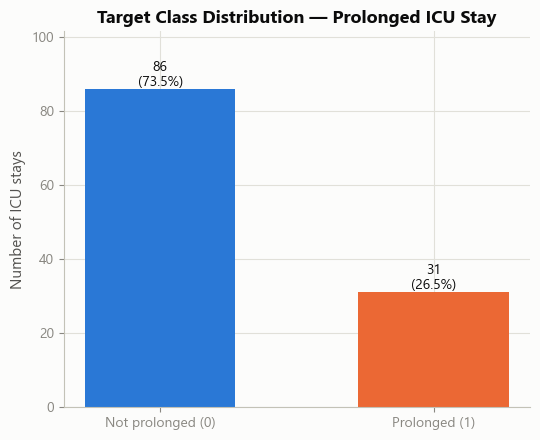

In [7]:
counts = df["prolonged_stay_label"].value_counts().sort_index()
pct = (df["prolonged_stay_label"].value_counts(normalize=True).sort_index() * 100)

print("Class counts:")
for label in counts.index:
    print(f"  {TARGET_LABELS[label]:<22s} n={counts[label]:>4}   ({pct[label]:.1f}%)")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
bars = ax.bar(
    [TARGET_LABELS[l] for l in counts.index],
    counts.values,
    color=[TARGET_COLORS[l] for l in counts.index],
    width=0.55,
)
for b, label in zip(bars, counts.index):
    ax.annotate(f"{counts[label]}\n({pct[label]:.1f}%)",
                (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", fontsize=10, color=INK_PRIMARY)
ax.set_title("Target Class Distribution — Prolonged ICU Stay")
ax.set_ylabel("Number of ICU stays")
ax.set_ylim(0, counts.max() * 1.18)
save_fig(fig, "target_class_distribution")

**Interpretation.** The target is moderately imbalanced: 86 stays (73.5%) are
not prolonged and 31 stays (26.5%) are prolonged, at the provisional 5-day LOS
threshold. This is a real but manageable imbalance — roughly 1:2.8 — not the
severe (e.g. 1:50) imbalance that would force techniques like SMOTE. It does
mean plain accuracy will be a misleading metric later (a model predicting
"not prolonged" for every stay would already score 73.5%), so stratified
cross-validation and imbalance-aware metrics (PR-AUC, F1, calibration — all
already specified in the project proposal) will matter at the modeling stage.
No class-balancing action is taken in this notebook; this is purely a
descriptive observation for Part 9.

## Part 4 — Numerical Feature Analysis

In [8]:
def analyze_numeric(df, col, filename):
    s = df[col]
    stats = s.describe()
    skew = s.skew()
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = s[(s < lo) | (s > hi)]

    print(f"--- {col} ---")
    print(stats.to_string())
    print(f"skew: {skew:.3f}")
    print(f"IQR outlier bounds: [{lo:.2f}, {hi:.2f}]  ->  {len(outliers)} outlier(s)")
    if len(outliers) > 0:
        print(f"outlier values: {sorted(outliers.tolist())}")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].hist(s, bins=20, color=BLUE, edgecolor=SURFACE, linewidth=0.6)
    axes[0].axvline(s.mean(), color=RED, linestyle="--", linewidth=1.4, label=f"mean={s.mean():.2f}")
    axes[0].axvline(s.median(), color=INK_PRIMARY, linestyle=":", linewidth=1.4, label=f"median={s.median():.2f}")
    axes[0].set_title(f"{col} — Histogram")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")
    axes[0].legend(fontsize=9, frameon=False)

    axes[1].boxplot(s.dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor=BLUE, edgecolor=INK_PRIMARY, alpha=0.75),
                     medianprops=dict(color=RED, linewidth=1.6),
                     flierprops=dict(marker="o", markerfacecolor=RED, markeredgecolor=RED, markersize=4, alpha=0.6))
    axes[1].set_title(f"{col} — Boxplot")
    axes[1].set_xticks([])
    axes[1].set_ylabel(col)

    save_fig(fig, filename)
    return stats, skew, outliers

--- age_at_admission ---
count    117.000000
mean      62.435897
std       15.954345
min       21.000000
25%       52.000000
50%       63.000000
75%       75.000000
max       92.000000
skew: -0.290
IQR outlier bounds: [17.50, 109.50]  ->  0 outlier(s)


Saved figure: reports/figures/num_age_at_admission.png


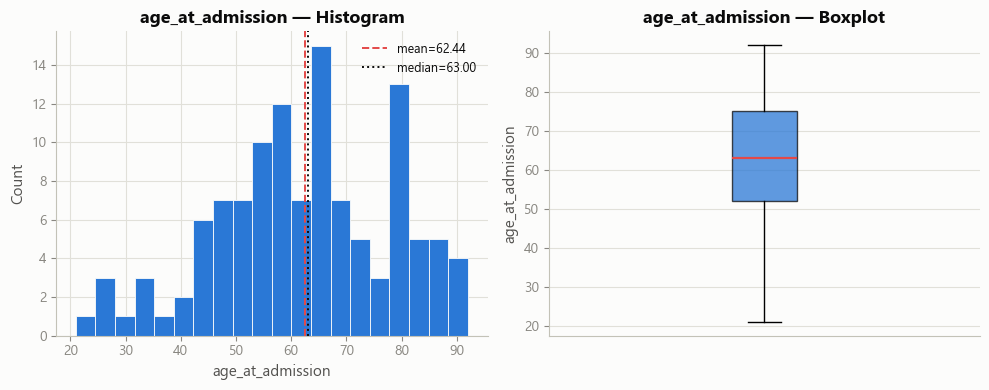

(count    117.000000
 mean      62.435897
 std       15.954345
 min       21.000000
 25%       52.000000
 50%       63.000000
 75%       75.000000
 max       92.000000
 Name: age_at_admission, dtype: float64,
 -0.2902561736044996,
 Series([], Name: age_at_admission, dtype: int64))

In [9]:
analyze_numeric(df, "age_at_admission", "num_age_at_admission")

**Interpretation.** `age_at_admission` is close to symmetric (skew ≈ -0.29),
median 63, IQR roughly 52-75, ranging from 21 to 92. Zero IQR outliers — this
is the cleanest-behaved numerical feature in the table, and the range
confirms the adult-only cohort restriction from `cohort_selection.sql`
behaved as designed (no implausible pediatric or >100 values).

--- first_creatinine ---
count    117.000000
mean       1.476923
std        1.820354
min        0.200000
25%        0.700000
50%        0.900000
75%        1.600000
max       15.200000
skew: 4.701
IQR outlier bounds: [-0.65, 2.95]  ->  12 outlier(s)
outlier values: [3.0, 3.0, 3.3, 3.4, 3.5, 4.5, 5.1, 5.1, 5.8, 7.2, 7.9, 15.2]


Saved figure: reports/figures/num_first_creatinine.png


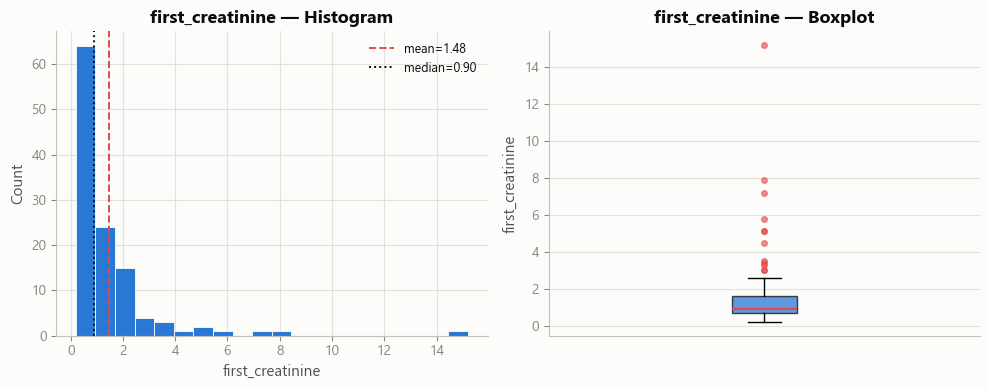

(count    117.000000
 mean       1.476923
 std        1.820354
 min        0.200000
 25%        0.700000
 50%        0.900000
 75%        1.600000
 max       15.200000
 Name: first_creatinine, dtype: float64,
 4.701494422823211,
 0      7.9
 7      3.0
 23     3.4
 31     5.1
 33     5.1
 36    15.2
 37     5.8
 47     7.2
 70     3.3
 77     4.5
 85     3.0
 90     3.5
 Name: first_creatinine, dtype: float64)

In [10]:
analyze_numeric(df, "first_creatinine", "num_first_creatinine")

**Interpretation.** Heavily right-skewed (skew ≈ 4.70): most stays cluster
at a normal creatinine (median 0.9 mg/dL) but a long tail extends to 15.2
mg/dL, with 12 IQR-flagged values above ~2.95. This shape is clinically
expected — renal function is usually normal but a meaningful minority of ICU
patients have acute or chronic severe renal failure. See Part 8 for why these
extreme values should not be treated as errors by default.

--- first_wbc ---
count    117.000000
mean      13.610256
std       12.821845
min        0.400000
25%        8.100000
50%       11.000000
75%       14.800000
max      116.100000
skew: 5.174
IQR outlier bounds: [-1.95, 24.85]  ->  7 outlier(s)
outlier values: [36.8, 40.7, 41.1, 45.6, 46.6, 52.8, 116.1]


Saved figure: reports/figures/num_first_wbc.png


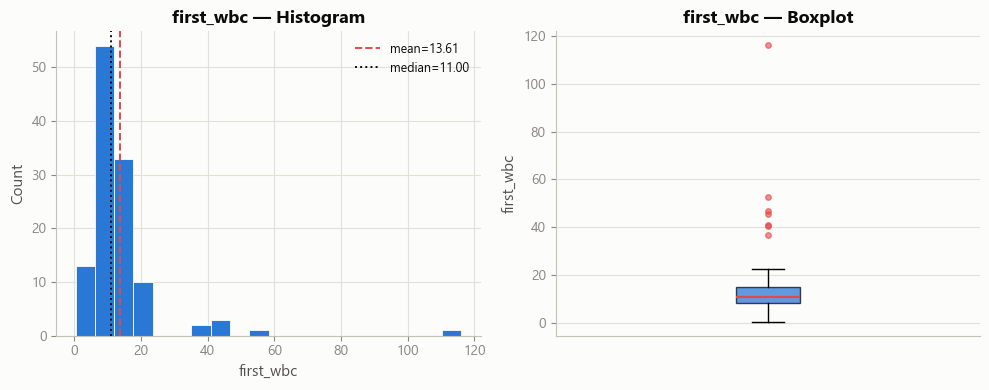

(count    117.000000
 mean      13.610256
 std       12.821845
 min        0.400000
 25%        8.100000
 50%       11.000000
 75%       14.800000
 max      116.100000
 Name: first_wbc, dtype: float64,
 5.173974096156531,
 6       36.8
 12      40.7
 13      41.1
 61     116.1
 63      46.6
 86      45.6
 110     52.8
 Name: first_wbc, dtype: float64)

In [11]:
analyze_numeric(df, "first_wbc", "num_first_wbc")

**Interpretation.** Even more skewed than creatinine (skew ≈ 5.17), median
11.0 K/uL against a maximum of 116.1 K/uL, with 7 IQR-flagged high values.
Marked leukocytosis is a hallmark of severe infection/inflammatory response,
so a heavy right tail is expected in an ICU population — though the single
116.1 value is extreme enough to warrant the clinical-vs-error discussion in
Part 8 rather than an immediate judgment either way.

--- first_hemoglobin ---
count    117.000000
mean      10.397436
std        1.963875
min        5.600000
25%        9.200000
50%       10.400000
75%       11.600000
max       16.000000
skew: 0.239
IQR outlier bounds: [5.60, 15.20]  ->  2 outlier(s)
outlier values: [15.5, 16.0]


Saved figure: reports/figures/num_first_hemoglobin.png


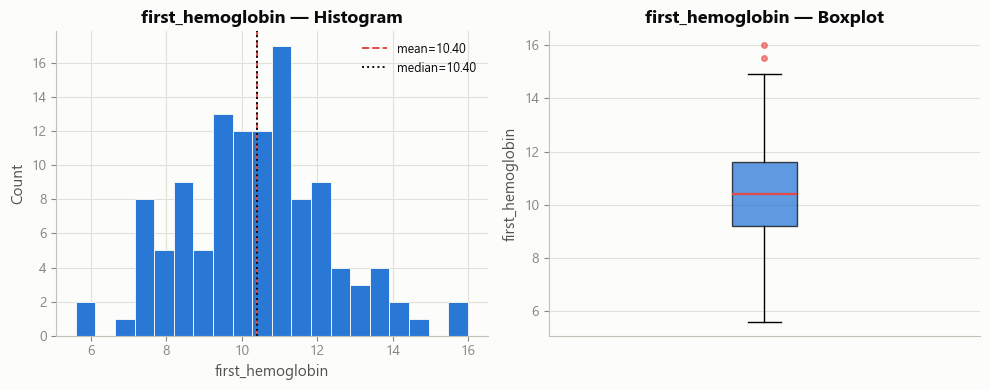

(count    117.000000
 mean      10.397436
 std        1.963875
 min        5.600000
 25%        9.200000
 50%       10.400000
 75%       11.600000
 max       16.000000
 Name: first_hemoglobin, dtype: float64,
 0.23927872291367977,
 46    15.5
 48    16.0
 Name: first_hemoglobin, dtype: float64)

In [12]:
analyze_numeric(df, "first_hemoglobin", "num_first_hemoglobin")

**Interpretation.** Nearly symmetric (skew ≈ 0.24), median 10.4 g/dL — notably
below the general-population normal range, consistent with anemia being
common in critically ill patients. Only 2 mild IQR outliers, both on the
high side (15.5, 16.0) and still within a normal physiological range — a
good example of a statistical outlier that is not a clinical concern.

--- medication_count ---
count    117.000000
mean      18.324786
std        8.274211
min        0.000000
25%       12.000000
50%       17.000000
75%       24.000000
max       40.000000
skew: 0.313
IQR outlier bounds: [-6.00, 42.00]  ->  0 outlier(s)


Saved figure: reports/figures/num_medication_count.png


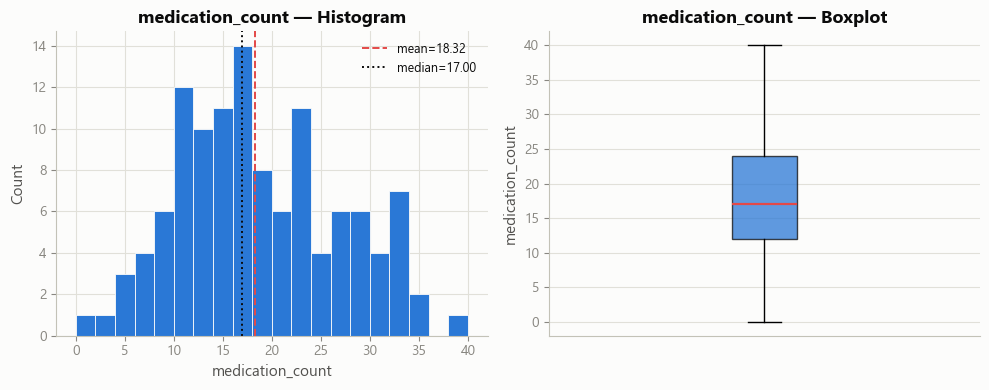

(count    117.000000
 mean      18.324786
 std        8.274211
 min        0.000000
 25%       12.000000
 50%       17.000000
 75%       24.000000
 max       40.000000
 Name: medication_count, dtype: float64,
 0.3129693146978429,
 Series([], Name: medication_count, dtype: int64))

In [13]:
analyze_numeric(df, "medication_count", "num_medication_count")

**Interpretation.** Mildly right-skewed (skew ≈ 0.31), median 17 distinct
first-24h medications, ranging 0-40, with zero IQR outliers. The spread is
consistent with the heterogeneity of ICU order sets (fluids, electrolytes,
analgesia, prophylaxis, etc. all count toward this feature per its SQL
definition in `medications_first24h.sql`).

--- comorbidity_count ---
count    117.000000
mean       1.512821
std        1.164233
min        0.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        4.000000
skew: 0.402
IQR outlier bounds: [-0.50, 3.50]  ->  6 outlier(s)
outlier values: [4, 4, 4, 4, 4, 4]


Saved figure: reports/figures/num_comorbidity_count.png


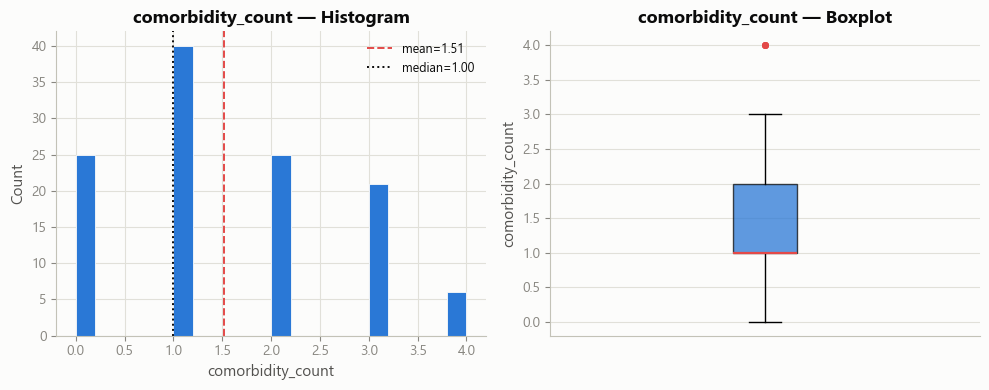

(count    117.000000
 mean       1.512821
 std        1.164233
 min        0.000000
 25%        1.000000
 50%        1.000000
 75%        2.000000
 max        4.000000
 Name: comorbidity_count, dtype: float64,
 0.40198852669455654,
 15    4
 46    4
 80    4
 87    4
 88    4
 93    4
 Name: comorbidity_count, dtype: int64)

In [14]:
analyze_numeric(df, "comorbidity_count", "num_comorbidity_count")

**Interpretation.** Mildly right-skewed (skew ≈ 0.40), median 1, and the 6
values IQR-flags as "outliers" are all exactly 4 — the maximum possible
value, since this feature is the sum of exactly 4 binary comorbidity flags.
This is the clearest case in the dataset of a statistical outlier rule
flagging a value that is not actually anomalous, just at the natural ceiling
of a bounded count variable.

## Part 5 — Categorical Feature Analysis

In [15]:
FRIENDLY_LABELS = {
    "weekend_admission": {0: "Weekday", 1: "Weekend"},
    "night_admission": {0: "Day (08:00-20:00)", 1: "Night (20:00-08:00)"},
    "diabetes_flag": {0: "No diabetes", 1: "Diabetes"},
    "hypertension_flag": {0: "No hypertension", 1: "Hypertension"},
    "ckd_flag": {0: "No CKD", 1: "CKD"},
    "heart_failure_flag": {0: "No heart failure", 1: "Heart failure"},
    "antibiotic_flag": {0: "No antibiotic (24h)", 1: "Antibiotic (24h)"},
    "insulin_flag": {0: "No insulin (24h)", 1: "Insulin (24h)"},
}

def analyze_categorical(df, col, filename):
    vc = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100
    labels = [FRIENDLY_LABELS.get(col, {}).get(v, str(v)) for v in vc.index]

    print(f"--- {col} ---")
    table = pd.DataFrame({"count": vc, "pct": pct.round(1)})
    table.index = labels
    print(table.to_string())

    colors = [CAT_PALETTE[i % len(CAT_PALETTE)] for i in range(len(vc))]
    fig, ax = plt.subplots(figsize=(max(5.5, 0.9 * len(vc) + 3), 4.5))
    bars = ax.bar(labels, vc.values, color=colors, width=0.6)
    for b, v, p in zip(bars, vc.values, pct.values):
        ax.annotate(f"{v} ({p:.1f}%)", (b.get_x() + b.get_width() / 2, b.get_height()),
                    ha="center", va="bottom", fontsize=9, color=INK_PRIMARY)
    ax.set_title(f"{col} — Frequency Distribution")
    ax.set_ylabel("Number of ICU stays")
    ax.set_ylim(0, vc.max() * 1.2)
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    save_fig(fig, filename)
    return table

--- gender ---
   count   pct
M     63  53.8
F     54  46.2


Saved figure: reports/figures/cat_gender.png


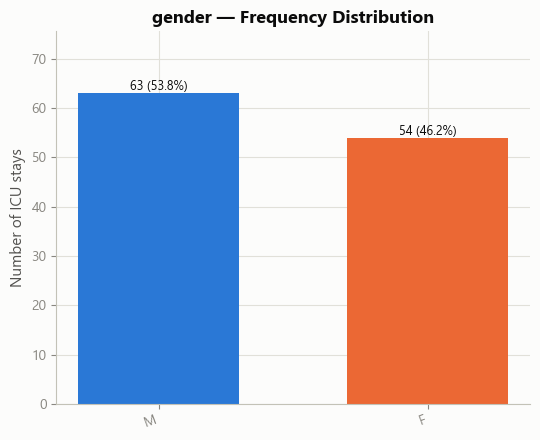

,count,pct
M,63,53.8
F,54,46.2


In [16]:
analyze_categorical(df, "gender", "cat_gender")

**Distribution.** Reasonably balanced: 53.8% male, 46.2% female.

--- admission_type ---
                             count   pct
EW EMER.                        50  42.7
URGENT                          30  25.6
OBSERVATION ADMIT               16  13.7
SURGICAL SAME DAY ADMISSION     13  11.1
ELECTIVE                         4   3.4
DIRECT EMER.                     4   3.4


Saved figure: reports/figures/cat_admission_type.png


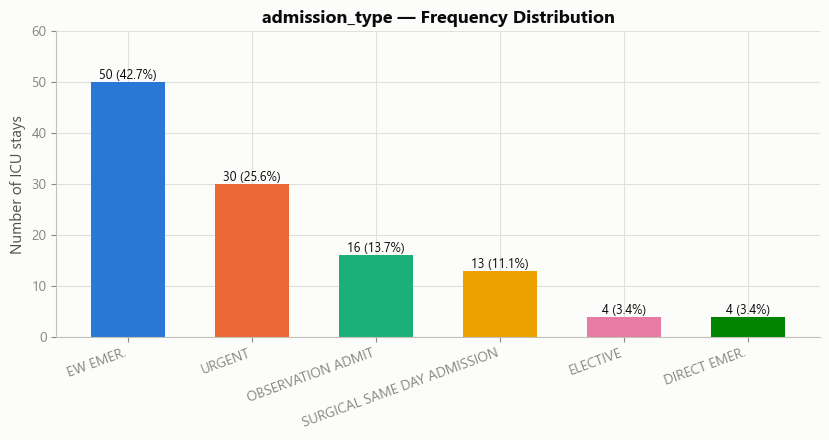

,count,pct
EW EMER.,50,42.7
URGENT,30,25.6
OBSERVATION ADMIT,16,13.7
SURGICAL SAME DAY ADMISSION,13,11.1
ELECTIVE,4,3.4
DIRECT EMER.,4,3.4


In [17]:
analyze_categorical(df, "admission_type", "cat_admission_type")

**Distribution.** Dominated by emergent admissions — `EW EMER.` (42.7%) and `URGENT` (25.6%) together account for over two-thirds of stays — with `ELECTIVE` and `DIRECT EMER.` each a small minority (3.4%).

--- insurance ---
          count   pct
Other        64  54.7
Medicare     44  37.6
Medicaid      9   7.7


Saved figure: reports/figures/cat_insurance.png


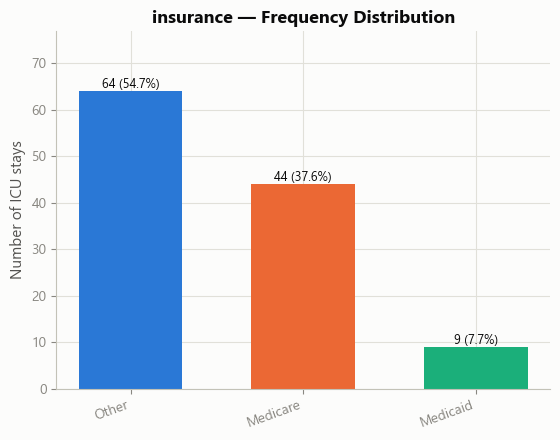

,count,pct
Other,64,54.7
Medicare,44,37.6
Medicaid,9,7.7


In [18]:
analyze_categorical(df, "insurance", "cat_insurance")

**Distribution.** `Other` (54.7%) and `Medicare` (37.6%) dominate; only 7.7% are `Medicaid`. The high Medicare share is consistent with the cohort's median age of 63 (Medicare eligibility begins at 65).

--- weekend_admission ---
         count   pct
Weekday     89  76.1
Weekend     28  23.9


Saved figure: reports/figures/cat_weekend_admission.png


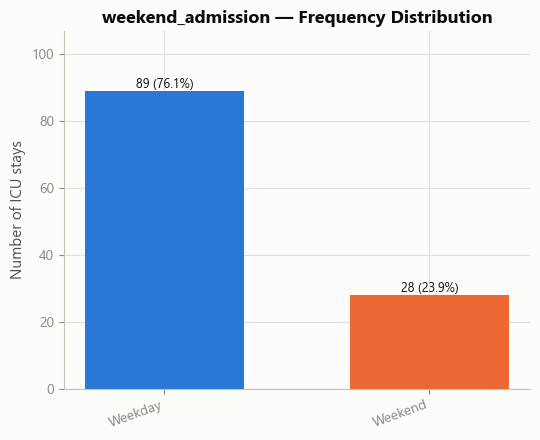

,count,pct
Weekday,89,76.1
Weekend,28,23.9


In [19]:
analyze_categorical(df, "weekend_admission", "cat_weekend_admission")

**Distribution.** 76.1% weekday vs. 23.9% weekend admissions, roughly matching the 5/7 calendar split expected if admissions were day-of-week-independent.

--- night_admission ---
                     count   pct
Day (08:00-20:00)       75  64.1
Night (20:00-08:00)     42  35.9


Saved figure: reports/figures/cat_night_admission.png


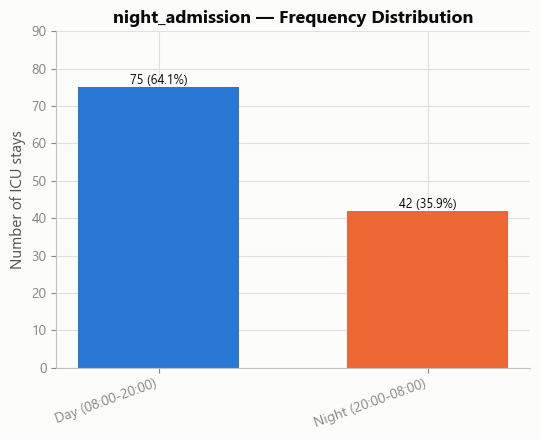

,count,pct
Day (08:00-20:00),75,64.1
Night (20:00-08:00),42,35.9


In [20]:
analyze_categorical(df, "night_admission", "cat_night_admission")

**Distribution.** 64.1% day vs. 35.9% night admissions — night admissions are somewhat under-represented relative to the 12/24 calendar split, plausible given elective/scheduled admissions concentrate during the day.

--- diabetes_flag ---
             count   pct
No diabetes     74  63.2
Diabetes        43  36.8


Saved figure: reports/figures/cat_diabetes_flag.png


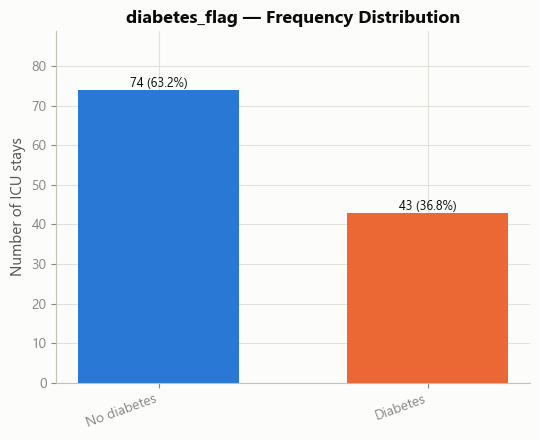

,count,pct
No diabetes,74,63.2
Diabetes,43,36.8


In [21]:
analyze_categorical(df, "diabetes_flag", "cat_diabetes_flag")

**Distribution.** 36.8% of stays are flagged with pre-existing diabetes.

--- hypertension_flag ---
                 count   pct
Hypertension        75  64.1
No hypertension     42  35.9


Saved figure: reports/figures/cat_hypertension_flag.png


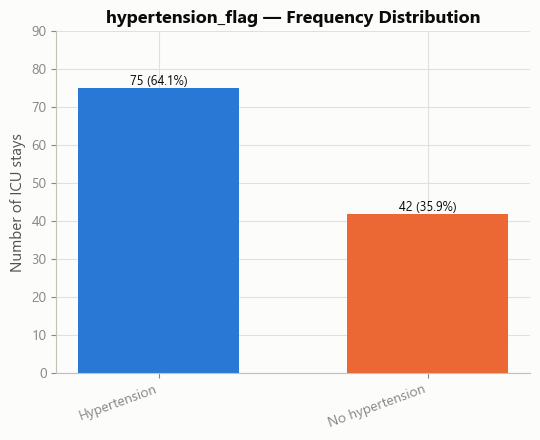

,count,pct
Hypertension,75,64.1
No hypertension,42,35.9


In [22]:
analyze_categorical(df, "hypertension_flag", "cat_hypertension_flag")

**Distribution.** The most prevalent comorbidity by far: 64.1% of stays are flagged with hypertension — consistent with the cohort's older median age.

--- ckd_flag ---
        count   pct
No CKD     89  76.1
CKD        28  23.9


Saved figure: reports/figures/cat_ckd_flag.png


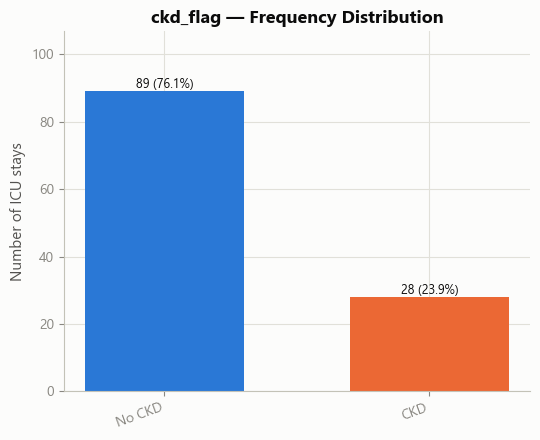

,count,pct
No CKD,89,76.1
CKD,28,23.9


In [23]:
analyze_categorical(df, "ckd_flag", "cat_ckd_flag")

**Distribution.** 23.9% of stays are flagged with chronic kidney disease.

--- heart_failure_flag ---
                  count   pct
No heart failure     86  73.5
Heart failure        31  26.5


Saved figure: reports/figures/cat_heart_failure_flag.png


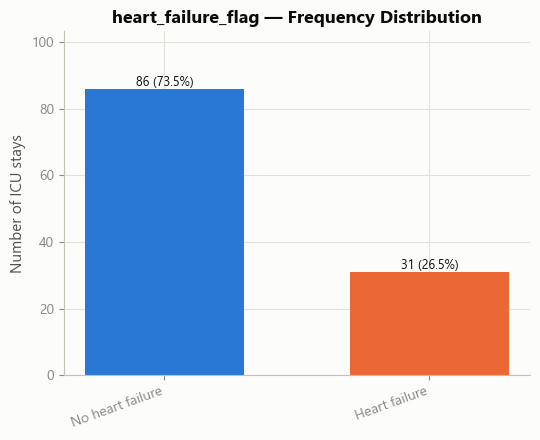

,count,pct
No heart failure,86,73.5
Heart failure,31,26.5


In [24]:
analyze_categorical(df, "heart_failure_flag", "cat_heart_failure_flag")

**Distribution.** 26.5% of stays are flagged with heart failure.

--- antibiotic_flag ---
                     count   pct
Antibiotic (24h)        77  65.8
No antibiotic (24h)     40  34.2


Saved figure: reports/figures/cat_antibiotic_flag.png


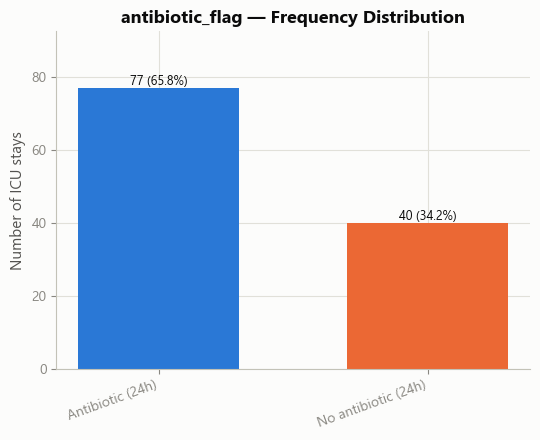

,count,pct
Antibiotic (24h),77,65.8
No antibiotic (24h),40,34.2


In [25]:
analyze_categorical(df, "antibiotic_flag", "cat_antibiotic_flag")

**Distribution.** A majority — 65.8% — received a systemic antibiotic within the first 24 hours, consistent with an ICU population where empiric antibiotic therapy for suspected infection is common.

--- insulin_flag ---
                  count   pct
Insulin (24h)        60  51.3
No insulin (24h)     57  48.7


Saved figure: reports/figures/cat_insulin_flag.png


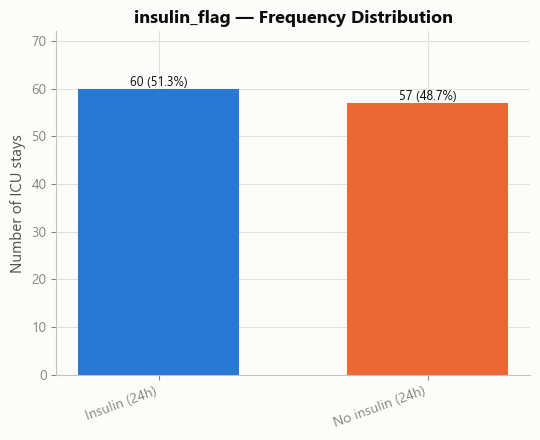

,count,pct
Insulin (24h),60,51.3
No insulin (24h),57,48.7


In [26]:
analyze_categorical(df, "insulin_flag", "cat_insulin_flag")

**Distribution.** Close to an even split: 51.3% received insulin in the first 24 hours vs. 48.7% who did not — reflecting both diabetes management and stress-hyperglycemia protocols common in critical illness, not diabetes prevalence alone (36.8%).

## Part 6 — Relationship with Target

### Numerical features vs. target

Saved figure: reports/figures/target_vs_age_at_admission.png


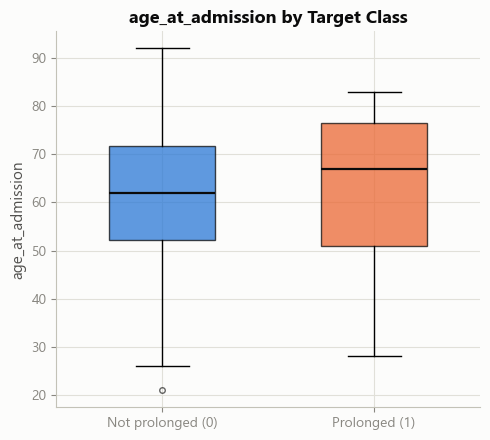

Saved figure: reports/figures/target_vs_first_creatinine.png


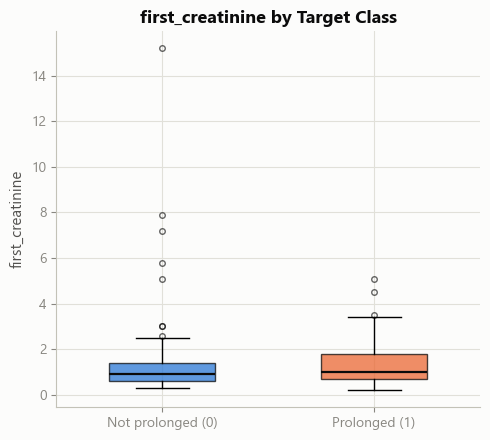

Saved figure: reports/figures/target_vs_first_wbc.png


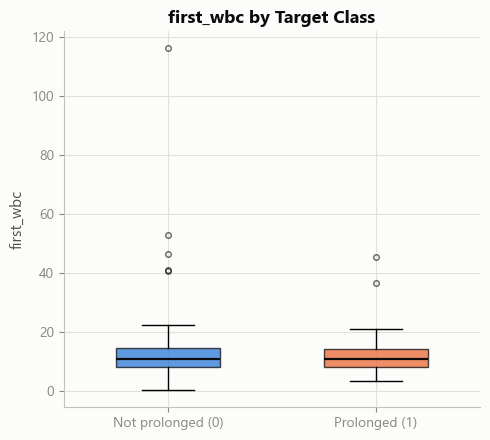

Saved figure: reports/figures/target_vs_first_hemoglobin.png


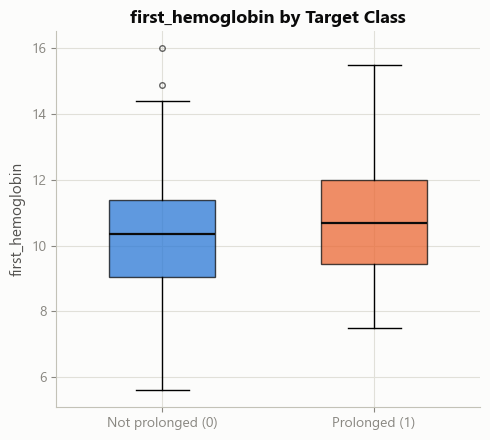

Saved figure: reports/figures/target_vs_medication_count.png


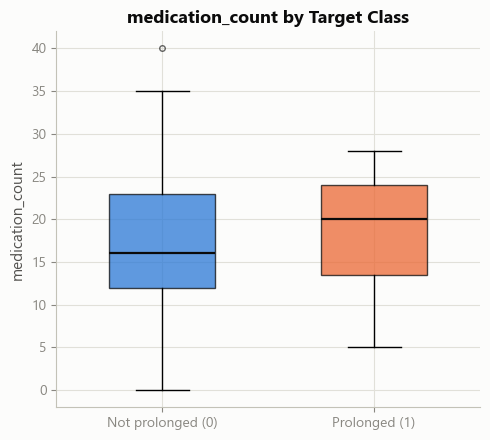

Saved figure: reports/figures/target_vs_comorbidity_count.png


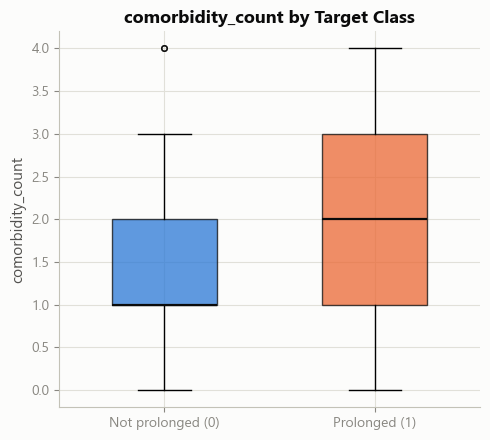

Saved: ['target_vs_age_at_admission', 'target_vs_first_creatinine', 'target_vs_first_wbc', 'target_vs_first_hemoglobin', 'target_vs_medication_count', 'target_vs_comorbidity_count']


In [27]:
fig_names = []
for col in NUMERICAL_COLS:
    fig, ax = plt.subplots(figsize=(5, 4.5))
    data_by_label = [df.loc[df["prolonged_stay_label"] == l, col].dropna() for l in [0, 1]]
    bp = ax.boxplot(data_by_label, patch_artist=True, widths=0.5,
                     medianprops=dict(color=INK_PRIMARY, linewidth=1.6),
                     flierprops=dict(marker="o", markersize=4, alpha=0.6))
    for patch, l in zip(bp["boxes"], [0, 1]):
        patch.set_facecolor(TARGET_COLORS[l])
        patch.set_alpha(0.75)
        patch.set_edgecolor(INK_PRIMARY)
    ax.set_xticklabels([TARGET_LABELS[0], TARGET_LABELS[1]])
    ax.set_title(f"{col} by Target Class")
    ax.set_ylabel(col)
    fname = f"target_vs_{col}"
    save_fig(fig, fname)
    fig_names.append(fname)
print("Saved:", fig_names)

**Observable trends (numerical vs. target, descriptive only — no hypothesis
testing performed).** Group means/medians (from the underlying data, see
Part 1 summary statistics for full context):

- `comorbidity_count`: clearly higher among prolonged stays (mean 1.87 vs.
  1.38; median 2 vs. 1) — the most visible separation of the six numerical
  features.
- `age_at_admission`: slightly higher among prolonged stays (median 67 vs.
  62), a small but visible shift.
- `medication_count`: nearly identical between groups (mean 18.7 vs. 18.2) —
  little visible separation.
- `first_creatinine`: nearly identical medians (1.0 vs. 0.9) — little visible
  separation despite the feature's strong right skew.
- `first_hemoglobin`: slightly higher among prolonged stays (10.71 vs. 10.28)
  — a small shift, opposite the naive expectation that sicker patients would
  be more anemic.
- `first_wbc`: slightly *lower* among prolonged stays (mean 12.82 vs. 13.90)
  — counter to a naive "more inflammation, longer stay" expectation; likely
  reflects the heterogeneity of a 117-stay cohort rather than a real inverse
  relationship, and is not a pattern to over-interpret at this sample size.

### Categorical / binary features vs. target

Saved figure: reports/figures/target_vs_gender.png


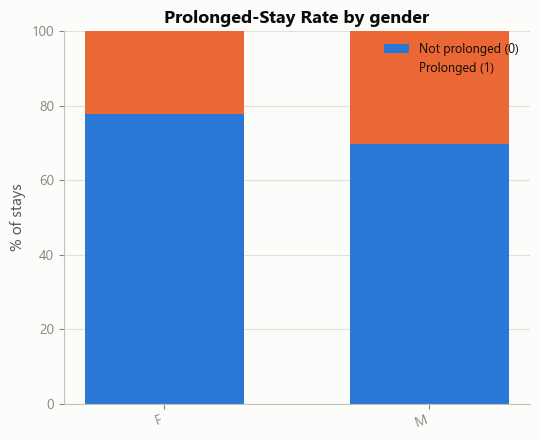

Saved figure: reports/figures/target_vs_admission_type.png


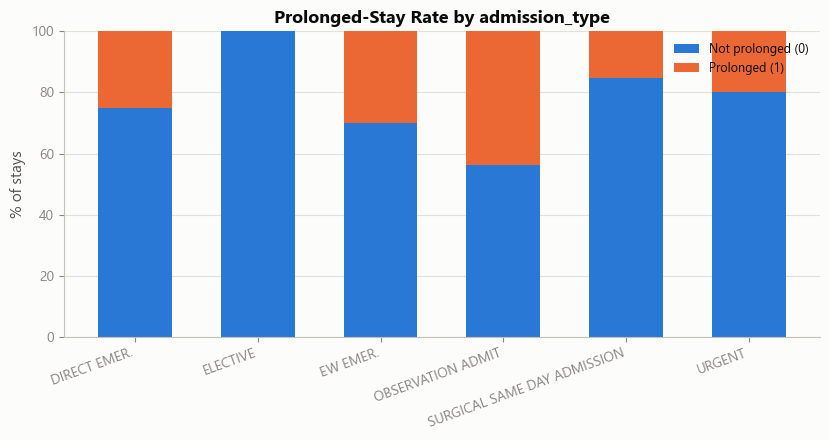

Saved figure: reports/figures/target_vs_insurance.png


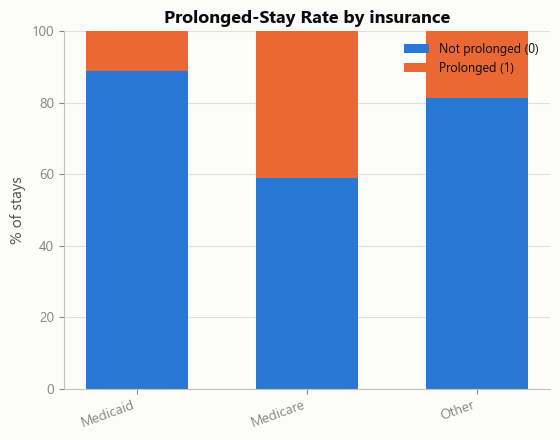

Saved figure: reports/figures/target_vs_weekend_admission.png


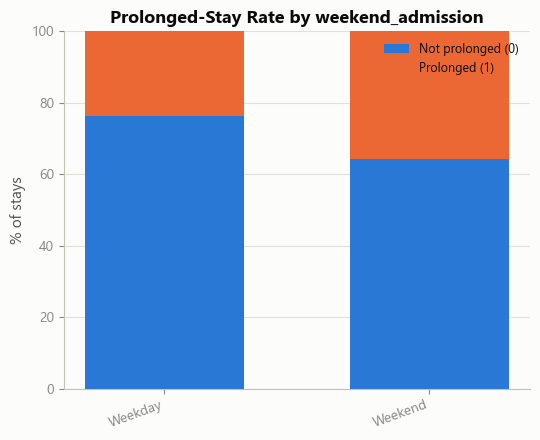

Saved figure: reports/figures/target_vs_night_admission.png


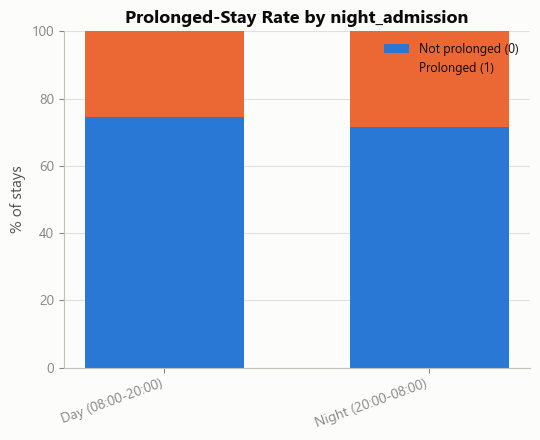

Saved figure: reports/figures/target_vs_diabetes_flag.png


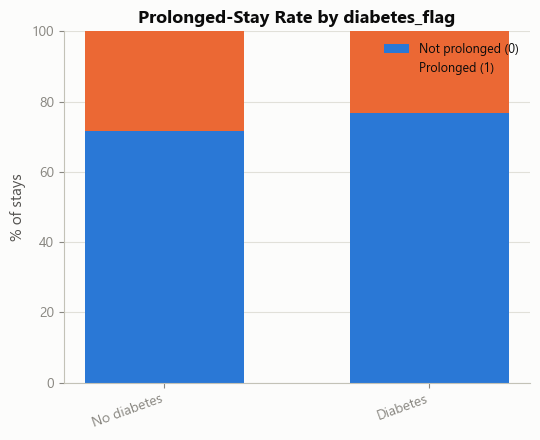

Saved figure: reports/figures/target_vs_hypertension_flag.png


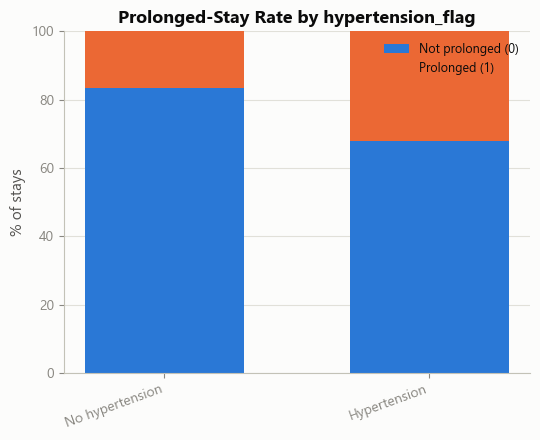

Saved figure: reports/figures/target_vs_ckd_flag.png


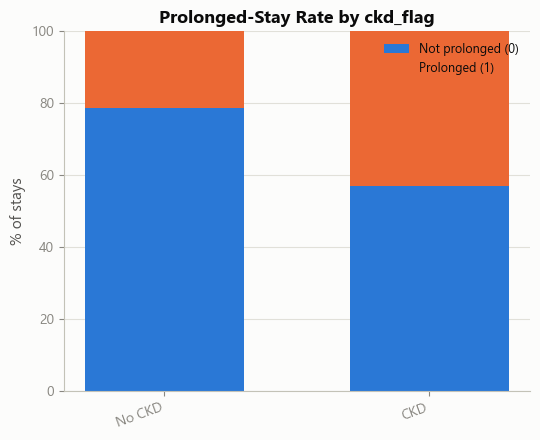

Saved figure: reports/figures/target_vs_heart_failure_flag.png


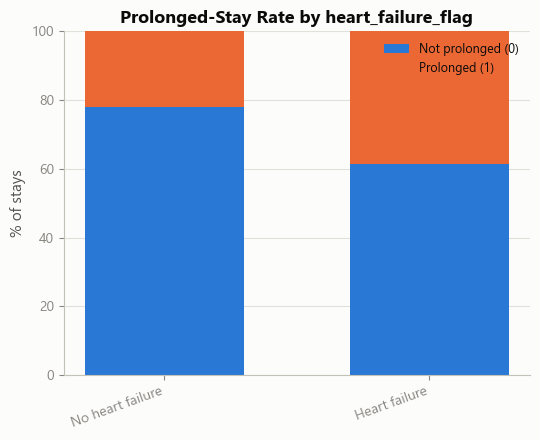

Saved figure: reports/figures/target_vs_antibiotic_flag.png


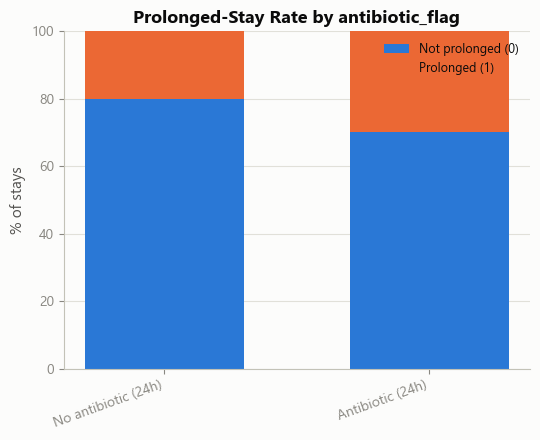

Saved figure: reports/figures/target_vs_insulin_flag.png


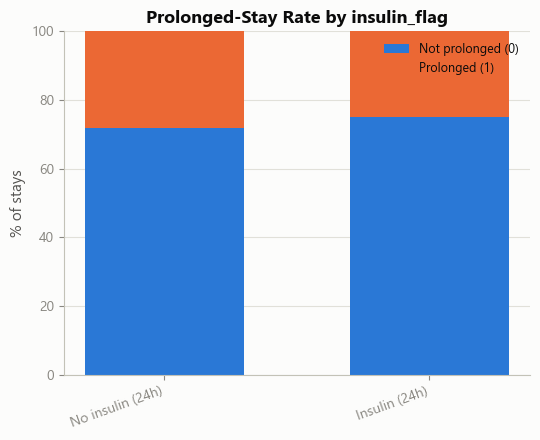

Saved: ['target_vs_gender', 'target_vs_admission_type', 'target_vs_insurance', 'target_vs_weekend_admission', 'target_vs_night_admission', 'target_vs_diabetes_flag', 'target_vs_hypertension_flag', 'target_vs_ckd_flag', 'target_vs_heart_failure_flag', 'target_vs_antibiotic_flag', 'target_vs_insulin_flag']


In [28]:
cat_and_binary_cols = CATEGORICAL_COLS + BINARY_COLS
fig_names = []
for col in cat_and_binary_cols:
    ct = pd.crosstab(df[col], df["prolonged_stay_label"], normalize="index") * 100
    ct = ct.reindex(columns=[0, 1], fill_value=0)
    labels = [FRIENDLY_LABELS.get(col, {}).get(v, str(v)) for v in ct.index]

    fig, ax = plt.subplots(figsize=(max(5.5, 0.9 * len(ct) + 3), 4.5))
    bottom = np.zeros(len(ct))
    for l in [0, 1]:
        vals = ct[l].values
        ax.bar(labels, vals, bottom=bottom, color=TARGET_COLORS[l],
               label=TARGET_LABELS[l], width=0.6)
        bottom += vals
    ax.set_title(f"Prolonged-Stay Rate by {col}")
    ax.set_ylabel("% of stays")
    ax.set_ylim(0, 100)
    ax.legend(fontsize=9, frameon=False, loc="upper right")
    plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
    fname = f"target_vs_{col}"
    save_fig(fig, fname)
    fig_names.append(fname)
print("Saved:", fig_names)

**Observable trends (categorical/binary vs. target, descriptive only).**
Prolonged-stay rate within each group (117 stays total, 26.5% baseline rate):

- `ckd_flag`: 42.9% prolonged when present vs. 21.3% when absent — the
  largest visible gap among the comorbidity flags.
- `heart_failure_flag`: 38.7% vs. 22.1% — a similarly sized gap.
- `hypertension_flag`: 32.0% vs. 16.7% — also a visible gap, though
  hypertension is present in 64% of the cohort so this split carries less
  discriminative weight than its size alone suggests.
- `weekend_admission`: 35.7% vs. 23.6% — a mild gap.
- `antibiotic_flag`: 29.9% vs. 20.0% — a mild gap.
- `diabetes_flag` and `insulin_flag`: both essentially flat or slightly
  *inverted* (diabetes: 23.3% vs. 28.4%; insulin: 25.0% vs. 28.1%) — the
  weakest, most counter-intuitive relationships in the table, worth
  revisiting once a real model is fit rather than assumed predictive here.
- `gender`: mild gap (male 30.2% vs. female 22.2%).
- `admission_type`: highest rate in `OBSERVATION ADMIT` (43.8%, n=16) and
  lowest in `ELECTIVE` (0%, n=4) — both small subgroups, so these extremes
  should be read cautiously rather than as strong signal.
- `insurance`: `Medicare` stands out at 40.9% vs. 18.8% (`Other`) and 11.1%
  (`Medicaid`) — plausibly an age/comorbidity proxy rather than an
  independent effect (see the fairness caveat already logged for this
  feature in `docs/feature_engineering_plan.md`).

## Part 7 — Correlation Analysis

Correlation with target (sorted):
ckd_flag              0.208
comorbidity_count     0.185
hypertension_flag     0.167
heart_failure_flag    0.166
weekend_admission     0.117
antibiotic_flag       0.106
first_hemoglobin      0.097
diabetes_flag        -0.056
first_wbc            -0.037
age_at_admission      0.037
night_admission       0.035
insulin_flag         -0.035
medication_count      0.030
first_creatinine      0.014

Top 10 absolute pairwise correlations among all features:
comorbidity_count  ckd_flag              0.685
                   heart_failure_flag    0.670
                   hypertension_flag     0.669
first_creatinine   ckd_flag              0.539
medication_count   insulin_flag          0.534
age_at_admission   hypertension_flag     0.525
comorbidity_count  diabetes_flag         0.519
age_at_admission   comorbidity_count     0.464
medication_count   antibiotic_flag       0.442
hypertension_flag  ckd_flag              0.378


Saved figure: reports/figures/correlation_heatmap.png


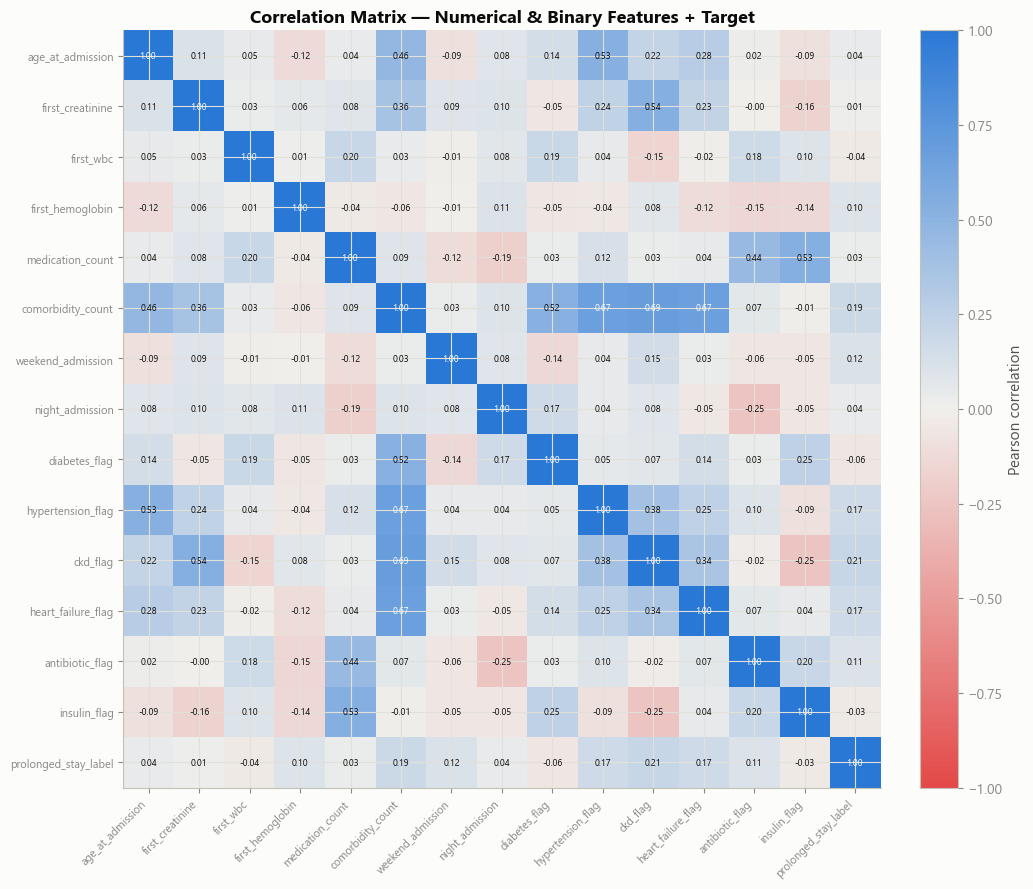

In [29]:
corr_cols = NUMERICAL_COLS + BINARY_COLS + ["prolonged_stay_label"]
corr = df[corr_cols].corr(numeric_only=True)

print("Correlation with target (sorted):")
print(corr["prolonged_stay_label"].drop("prolonged_stay_label").sort_values(key=lambda s: s.abs(), ascending=False).round(3).to_string())

mask_upper = np.triu(np.ones(corr.shape), k=1).astype(bool)
pair_corr = corr.where(mask_upper).stack().sort_values(key=lambda s: s.abs(), ascending=False)
print("\nTop 10 absolute pairwise correlations among all features:")
print(pair_corr.head(10).round(3).to_string())

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap=DIVERGING_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr.columns, fontsize=8)
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=6.5, color=INK_PRIMARY if abs(v) < 0.6 else "white")
ax.set_title("Correlation Matrix — Numerical & Binary Features + Target")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pearson correlation")
save_fig(fig, "correlation_heatmap")

**Interpretation.**

*Correlation with the target* is weak across the board — the strongest is
`ckd_flag` at r≈0.21, followed by `comorbidity_count` (r≈0.19),
`hypertension_flag` and `heart_failure_flag` (both r≈0.17). No feature
individually reaches even a moderate linear correlation with
`prolonged_stay_label`. This is expected at n=117 and is consistent with the
project's framing (`proposal.docx` §13): engineering rigor is the goal here,
not a strong linear univariate signal. It also motivates using nonlinear,
interaction-capturing models (Random Forest, XGBoost, per the proposal) at
the modeling stage rather than relying on linear separability.

*Correlation among features* surfaces one structural issue that must be
handled before modeling: `comorbidity_count` correlates strongly with
`ckd_flag` (r≈0.69), `heart_failure_flag` (r≈0.67), `hypertension_flag`
(r≈0.67), and `diabetes_flag` (r≈0.52) — **by construction**, since
`comorbidity_count` is defined in `sql/features/comorbidities.sql` as the sum
of exactly those four flags. This is not a discovered relationship, it is
mechanical, and it means the two representations (the flags and the count)
carry overlapping information — see Part 9.

Other correlations are clinically sensible and act as a face-validity check
on the SQL feature logic: `first_creatinine` ↔ `ckd_flag` (r≈0.54, elevated
creatinine tracking diagnosed kidney disease), `age_at_admission` ↔
`hypertension_flag` (r≈0.53, hypertension prevalence rising with age), and
`medication_count` ↔ `insulin_flag` / `antibiotic_flag` (r≈0.53 / r≈0.44,
mechanically expected since an insulin or antibiotic order itself
contributes to the medication count it's being compared against).

## Part 8 — Outlier Review

In [30]:
print(f"{'feature':<20s} {'n_outliers':>10s}  {'bounds (IQR 1.5x)':>22s}   extreme values")
print("-" * 90)
for col in NUMERICAL_COLS:
    s = df[col]
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out = s[(s < lo) | (s > hi)]
    bounds = f"[{lo:.2f}, {hi:.2f}]"
    extremes = sorted(out.tolist())[-5:] if len(out) else []
    print(f"{col:<20s} {len(out):>10d}  {bounds:>22s}   {extremes}")

feature              n_outliers       bounds (IQR 1.5x)   extreme values
------------------------------------------------------------------------------------------
age_at_admission              0         [17.50, 109.50]   []
first_creatinine             12           [-0.65, 2.95]   [5.1, 5.8, 7.2, 7.9, 15.2]
first_wbc                     7          [-1.95, 24.85]   [41.1, 45.6, 46.6, 52.8, 116.1]
first_hemoglobin              2           [5.60, 15.20]   [15.5, 16.0]
medication_count              0          [-6.00, 42.00]   []
comorbidity_count             6           [-0.50, 3.50]   [4, 4, 4, 4, 4]


**Are these outliers likely true ICU patients or measurement errors?** Per
variable:

- **`first_wbc` (max 116.1 K/uL, 7 flagged values up to ~52.8):** extreme
  leukocytosis of this magnitude is rare but clinically real — it occurs in
  severe sepsis, leukemoid reactions, or hematologic malignancy, all
  plausible in a critical-care population. Nothing in the earlier SQL
  validation (unit consistency, reference-range sanity, itemid verification
  — see `docs/data_dictionary.md` §5) suggested a unit-conversion or
  itemid-mapping error for this lab. Treated as a genuine clinical extreme.
- **`first_creatinine` (max 15.2 mg/dL, 12 flagged values):** consistent with
  severe/dialysis-dependent renal failure, a recognized driver of ICU
  complexity. Treated as genuine.
- **`comorbidity_count` (6 values, all exactly 4):** not a real outlier at
  all — 4 is the natural ceiling of a variable defined as the sum of 4 binary
  flags. The IQR rule flags it purely because the distribution is compact;
  it does not know the variable is bounded. This is the clearest case in the
  dataset of "statistical outlier ≠ clinically or structurally anomalous
  value."
- **`first_hemoglobin` (2 mild high-side values, 15.5 and 16.0):** both
  within a physiologically normal range — flagged only because the bulk of
  this ICU population runs anemic (median 10.4), making normal-range values
  look unusual by comparison within this specific cohort.
- **`age_at_admission`, `medication_count`:** zero IQR-flagged outliers.

**Why outliers are not removed here.** For a clinical severity-driven
prediction task, extreme lab values are frequently the most predictive
signal available — a patient with creatinine of 15 mg/dL is exactly the kind
of case a length-of-stay model needs to learn from, not discard. Blanket
removal would systematically strip out the sickest patients, biasing the
model toward the easy, unremarkable cases and defeating the purpose of the
task. Any transformation (e.g., log-scaling skewed labs, winsorizing at a
principled clinical bound) belongs in feature engineering, applied
deliberately and only if a specific model family requires it — not as an
automatic EDA-stage deletion rule.

## Part 9 — Modeling Readiness Assessment

In [31]:
print("Categorical cardinality (encoding scope):")
for c in CATEGORICAL_COLS:
    print(f"  {c:<16s} {df[c].nunique()} categories -> {df[c].nunique()} one-hot columns (or {df[c].nunique()-1} with drop-first)")

print("\nClass balance:")
rate = df['prolonged_stay_label'].mean()
print(f"  positive rate = {rate*100:.1f}%  (ratio approx 1 : {(1-rate)/rate:.2f})")

print("\nSkewness recap (numerical features):")
for c in NUMERICAL_COLS:
    print(f"  {c:<20s} skew={df[c].skew():.2f}")

print("\nScale range recap (numerical features, for scaling need):")
for c in NUMERICAL_COLS:
    print(f"  {c:<20s} min={df[c].min():<8g} max={df[c].max():<8g}")

Categorical cardinality (encoding scope):
  gender           2 categories -> 2 one-hot columns (or 1 with drop-first)
  admission_type   6 categories -> 6 one-hot columns (or 5 with drop-first)
  insurance        3 categories -> 3 one-hot columns (or 2 with drop-first)

Class balance:
  positive rate = 26.5%  (ratio approx 1 : 2.77)

Skewness recap (numerical features):
  age_at_admission     skew=-0.29
  first_creatinine     skew=4.70
  first_wbc            skew=5.17
  first_hemoglobin     skew=0.24
  medication_count     skew=0.31
  comorbidity_count    skew=0.40

Scale range recap (numerical features, for scaling need):
  age_at_admission     min=21       max=92      
  first_creatinine     min=0.2      max=15.2    
  first_wbc            min=0.4      max=116.1   
  first_hemoglobin     min=5.6      max=16      
  medication_count     min=0        max=40      
  comorbidity_count    min=0        max=4       


**Missing values.** None observed in this table, but see the Part 2 caveat —
absence here reflects `COALESCE(...,0)` design choices in the SQL pipeline
for the comorbidity/medication features, not proof that missingness can
never occur. The feature-engineering stage should still build defensive
missing-value handling (the plan already exists per-feature in
`docs/feature_engineering_plan.md`: missing-indicator + training-fold-median
imputation for the three lab features) rather than assuming this clean
0%-missing result generalizes to a larger cohort.

**Categorical encoding.** `gender` (2), `admission_type` (6), and
`insurance` (3) are still raw strings and need encoding before any model
that isn't natively categorical-aware. One-hot encoding is appropriate at
this low cardinality; no target/frequency encoding is needed.

**Scaling.** Feature scales vary widely (`age_at_admission` 21-92,
`comorbidity_count` 0-4, `medication_count` 0-40, `first_creatinine`
0.2-15.2). Scaling is required for the Logistic Regression baseline in the
proposal's modeling plan; Random Forest and XGBoost are scale-invariant and
need no adjustment.

**Class imbalance.** 73.5% / 26.5%, roughly 1:2.8. Recommend stratified
k-fold cross-validation (already a proposal principle) and
`class_weight="balanced"` (or equivalent) as the first-line handling.
Synthetic oversampling (SMOTE) is not recommended at this sample size — with
only 31 positive cases, synthetic interpolation risks manufacturing
unrealistic points rather than adding real signal. PR-AUC should be weighted
at least as heavily as ROC-AUC when comparing models, consistent with the
proposal's evaluation plan.

**Feature transformation.** `first_creatinine` (skew≈4.70) and `first_wbc`
(skew≈5.17) are heavily right-skewed. A log1p transform is worth evaluating
for the Logistic Regression baseline; tree-based models are invariant to
monotonic transforms and need no change.

**Multicollinearity.** `comorbidity_count` is a deterministic linear
function of `diabetes_flag` + `hypertension_flag` + `ckd_flag` +
`heart_failure_flag` (confirmed in Part 7, r≈0.52-0.69 with each). Carrying
both representations into a linear model is redundant and can destabilize
coefficient estimates; recommend choosing one representation per model
(e.g., keep the four flags for interpretability/SHAP, drop
`comorbidity_count`, or vice versa for a simpler baseline) rather than
including both blindly.

**Possible interaction features** (candidates for feature engineering, not
built here): `first_creatinine` × `ckd_flag` (does an elevated value mean
something different for a patient with known CKD vs. a new finding),
`age_at_admission` × `comorbidity_count`, and `admission_type` ×
`antibiotic_flag` (infection presenting emergently vs. electively).

**Sample size caveat.** With 117 stays and only 31 positive labels, this
remains a small dataset by machine-learning standards. Cross-validation fold
variance will be high and any single train/test split result should be
interpreted cautiously. This reinforces the project's own framing
(`proposal.docx` §13): the deliverable here is a rigorously engineered
pipeline and an honest, well-documented result — not a benchmark-chasing
model fit to noise.

## Summary

A full written summary of this notebook's findings — dataset overview, key
findings, data quality assessment, clinical observations, modeling
challenges, and recommended preprocessing steps — is saved separately as
`reports/EDA_summary.md`, formatted for inclusion in the project report.

In [32]:
n_figs = len(list(FIG_DIR.glob("*.png")))
print(f"Figures on disk in reports/figures/: {n_figs}")
print(f"Figures saved by this notebook run: {len(N_FIGURES_SAVED)}")
print()
print("EDA completed successfully.")

Figures on disk in reports/figures/: 36
Figures saved by this notebook run: 36

EDA completed successfully.
